# INVERTER CIRCUIT 7nm FINFET

> Path: /home/eduarda/Repos/Electrical-Behaviour-Prediction/FINFET/7nm/NOT/Data/sim1/simResults_NOTfet/all_results_inverter.csv

> https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction/tree/main/FINFET

## Data cleaning

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
dataset_path = '/home/eduarda/Repos/jupyter_ic/data/raw/FINFET/7nm/NOT/sim1/all_results_inverter.csv'
data = pd.read_csv(dataset_path, index_col=0)

Renaming columns

In [18]:
data = data.rename(columns={
    '1': 'PV_nfet', 
    '2': 'PV_pfet', 
    'vdd': 'voltage', 
    'LoadCap': 'capacitance',
    'number_fin': 'finsNumber',
    'temper': 'temperature',
    'iint': 'energy'
})

data

,PV_nfet,PV_pfet,capacitance,voltage,finsNumber,index,temp,montecarlo_iteration,tphl,tplh,total_power,energy,temperature,alter#
0,4.370067,4.852864,1f,0.6,1,1,-25,1,1.230100e-11,1.582600e-11,-9.601460e-09,-6.400970e-16,-25,1
1,4.370806,4.873612,1f,0.6,1,2,-25,2,1.232850e-11,1.470250e-11,-9.648810e-09,-6.432540e-16,-25,1
2,4.333499,4.850897,1f,0.6,1,3,-25,3,1.128970e-11,1.594150e-11,-9.603980e-09,-6.402650e-16,-25,1
3,4.407237,4.856645,1f,0.6,1,4,-25,4,1.353270e-11,1.560170e-11,-9.595290e-09,-6.396860e-16,-25,1
4,4.387795,4.770993,1f,0.6,1,5,-25,5,1.282430e-11,2.289280e-11,-9.530360e-09,-6.353580e-16,-25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,16f,0.9,5,596,100,96,3.889300e-11,3.870920e-11,-4.524430e-07,-2.010860e-14,100,1
47996,4.379719,4.855940,16f,0.9,5,597,100,97,4.406050e-11,3.445420e-11,-1.128870e-06,-5.017210e-14,100,1
47997,4.435190,4.791605,16f,0.9,5,598,100,98,5.173240e-11,3.773370e-11,-5.086850e-07,-2.260820e-14,100,1
47998,4.323838,4.781360,16f,0.9,5,599,100,99,3.772690e-11,3.840220e-11,-4.723270e-07,-2.099230e-14,100,1


Tranforming capacitance values to int

In [19]:
data['capacitance'].dtype

<StringDtype(storage='python', na_value=nan)>

In [20]:
data['capacitance'] = (
    data['capacitance']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(int)
)

data['capacitance'].dtype

dtype('int64')

Removing variables

In [21]:
data = data.drop("alter#", axis=1)
data = data.drop("index", axis=1)
data = data.drop("total_power", axis=1)
data = data.drop("montecarlo_iteration", axis=1)
data = data.drop("temp", axis=1)

In [22]:
nova_ordem = [
    'PV_nfet',
    'PV_pfet',
    'temperature',
    'voltage',
    'capacitance',
    'finsNumber',
    'tphl', 
    'tplh',
    'energy'
]

data = data[nova_ordem]

data

,PV_nfet,PV_pfet,temperature,voltage,capacitance,finsNumber,tphl,tplh,energy
0,4.370067,4.852864,-25,0.6,1,1,1.230100e-11,1.582600e-11,-6.400970e-16
1,4.370806,4.873612,-25,0.6,1,1,1.232850e-11,1.470250e-11,-6.432540e-16
2,4.333499,4.850897,-25,0.6,1,1,1.128970e-11,1.594150e-11,-6.402650e-16
3,4.407237,4.856645,-25,0.6,1,1,1.353270e-11,1.560170e-11,-6.396860e-16
4,4.387795,4.770993,-25,0.6,1,1,1.282430e-11,2.289280e-11,-6.353580e-16
...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,100,0.9,16,5,3.889300e-11,3.870920e-11,-2.010860e-14
47996,4.379719,4.855940,100,0.9,16,5,4.406050e-11,3.445420e-11,-5.017210e-14
47997,4.435190,4.791605,100,0.9,16,5,5.173240e-11,3.773370e-11,-2.260820e-14
47998,4.323838,4.781360,100,0.9,16,5,3.772690e-11,3.840220e-11,-2.099230e-14


In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PV_nfet      48000 non-null  float64
 1   PV_pfet      48000 non-null  float64
 2   temperature  48000 non-null  int64  
 3   voltage      48000 non-null  float64
 4   capacitance  48000 non-null  int64  
 5   finsNumber   48000 non-null  int64  
 6   tphl         48000 non-null  float64
 7   tplh         48000 non-null  float64
 8   energy       48000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 3.3 MB


In [24]:
data

,PV_nfet,PV_pfet,temperature,voltage,capacitance,finsNumber,tphl,tplh,energy
0,4.370067,4.852864,-25,0.6,1,1,1.230100e-11,1.582600e-11,-6.400970e-16
1,4.370806,4.873612,-25,0.6,1,1,1.232850e-11,1.470250e-11,-6.432540e-16
2,4.333499,4.850897,-25,0.6,1,1,1.128970e-11,1.594150e-11,-6.402650e-16
3,4.407237,4.856645,-25,0.6,1,1,1.353270e-11,1.560170e-11,-6.396860e-16
4,4.387795,4.770993,-25,0.6,1,1,1.282430e-11,2.289280e-11,-6.353580e-16
...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,100,0.9,16,5,3.889300e-11,3.870920e-11,-2.010860e-14
47996,4.379719,4.855940,100,0.9,16,5,4.406050e-11,3.445420e-11,-5.017210e-14
47997,4.435190,4.791605,100,0.9,16,5,5.173240e-11,3.773370e-11,-2.260820e-14
47998,4.323838,4.781360,100,0.9,16,5,3.772690e-11,3.840220e-11,-2.099230e-14


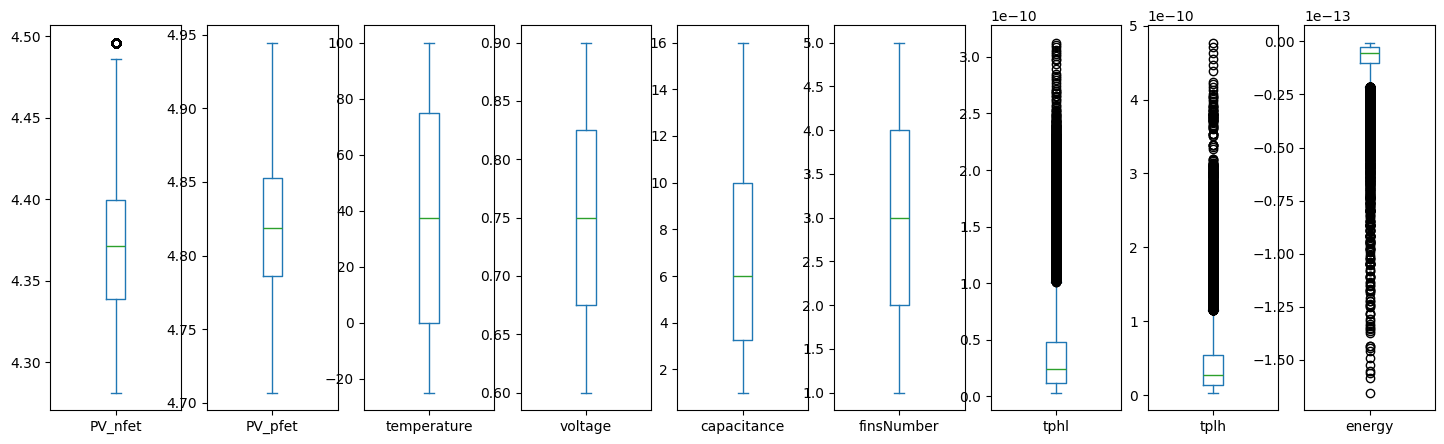

<Figure size 640x480 with 0 Axes>

In [25]:
data.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

In [26]:
## Removing outliers

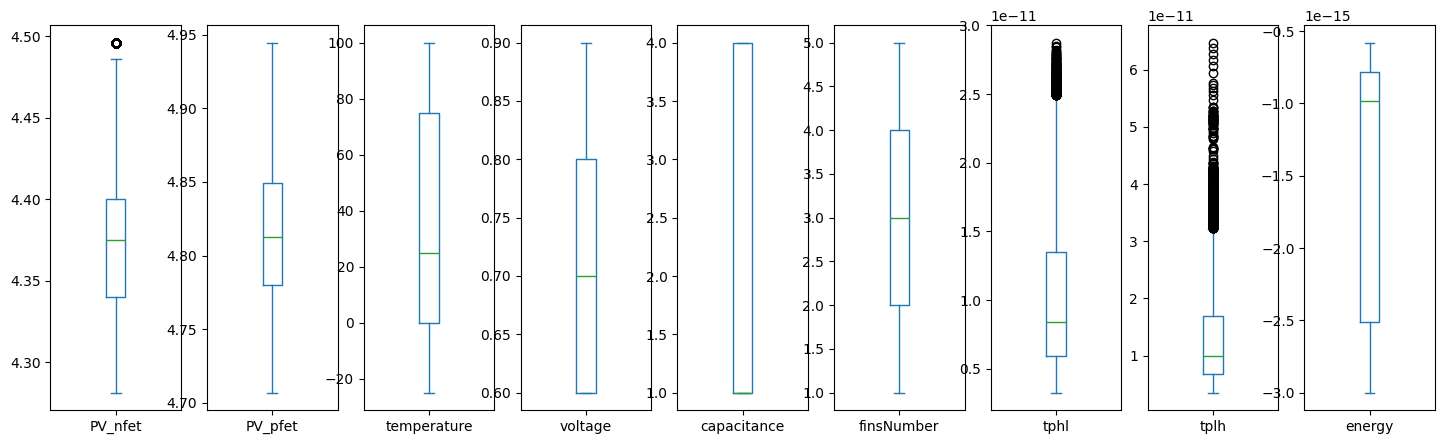

<Figure size 640x480 with 0 Axes>

In [27]:
# Outliers
data = data[(2e-12<=data.tphl)&(data.tphl<=2.9e-11)]
data = data[(1e-12<=data.tplh)&(data.tplh<=6.8e-11)]
data = data[(-3e-15<=data.energy)]

data.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

Some capacitance values are blank

In [28]:
data['capacitance'].value_counts()

capacitance
1    10253
4     3962
Name: count, dtype: int64

In [29]:
data.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/FINFET/7nm/NOT/01_data_cleaning/finfet_df.csv', index=True)